# 一、监督学习
监督学习是指利用一组已知类别的样本训练模型的参数，使其对未见过的新数据做出准确预测。

In [ ]:
#导入通用库
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  #matplotlib的高级统计绘图库
import graphviz  

#监督学习模型
#线性回归
from sklearn.linear_model import LinearRegression  
#逻辑回归
from sklearn.linear_model import LogisticRegression
#决策树
from sklearn.tree import DecisionTreeClassifier
#贝叶斯
from sklearn.naive_bayes import GaussianNB #贝叶斯-高斯模型
from sklearn.navie_bayes import MultinomiaINB #贝叶斯-多项式模型
#数据处理
from sklearn.model_selection import train_test_split   #数据集划分
from sklearn.preprocessing import StandardScaler      #特征工程、标准化处理
from sklearn.metrics import classification_report,roc_auc_score
import warnings
warnings.filterwarnings('ignore')

## 1.线性回归-回归问题
线性回归是最基础的回归算法，其目标是使训练集的预测值与真实值之间的均方误差最小。

### 1.1实现梯度下降的线性回归
步骤：
  * 1.生成模拟数据
  * 2.梯度下降算法
  * 3.结果可视化

训练完成，截距 b = 4.2148，权重 w = 2.7704
真实参数：截距 4，权重 3


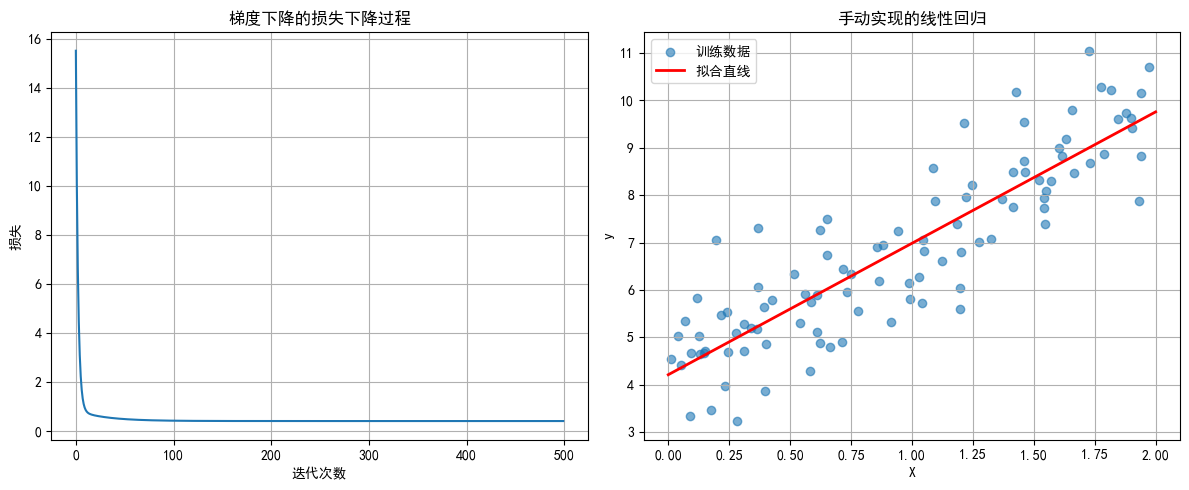

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 注意：解决中文显示问题 
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1.生成模拟数据 
np.random.seed(42)
m = 100  #100个数据点
X = 2 * np.random.rand(m, 1)      #生成（100，1）的二维数组，元素取值范围为[0，2)  
y = 4 + 3 * X + np.random.randn(m, 1)  #给出了真实线性关系，并模拟噪声，使数据更真实
X_b = np.c_[np.ones((m, 1)), X]   #将模型转变为纯矩阵运算

# 2.梯度下降算法 
# 初始化模型参数向量（包括截距和权重）
w = np.random.randn(2, 1)
learning_rate = 0.1    
n_iterations = 500    # 迭代次数
loss_history = []     # 存储每轮损失，用于可视化下降过程
# 算法主体
for iteration in range(n_iterations):
    # --- 前向计算：预测值 ---
    y_pred = X_b.dot(w)                   

    # --- 计算当前损失（均方误差/2）---
    loss = (1/(2*m)) * np.sum((y_pred - y) ** 2)
    loss_history.append(loss)

    # --- 计算梯度 ---
    # 损失关于 w 的梯度： (1/m) * X_b^T * (y_pred - y)
    gradients = (1/m) * X_b.T.dot(y_pred - y)   # 形状 (2,1)

    # --- 更新参数 ---
    w = w - learning_rate * gradients
# 最终学到的参数
print(f"训练完成，截距 b = {w[0][0]:.4f}，权重 w = {w[1][0]:.4f}")
print(f"真实参数：截距 4，权重 3")

# 3.可视化结果 
# 绘制损失下降曲线
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel("迭代次数")
plt.ylabel("损失")
plt.title("梯度下降的损失下降过程")
plt.grid(True)
# 绘制拟合直线与原始数据
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.6, label="训练数据")
# 按 X 从小到大取点画线
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(w)
plt.plot(X_new, y_predict, "r-", linewidth=2, label="拟合直线")
plt.xlabel("X")
plt.ylabel("y")
plt.title("手动实现的线性回归")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 1.2  使用scikit-learn 的线性回归
步骤：
* 1.数据加载（使用官方糖尿病数据集）
* 2.数据划分
* 3.特征工程
* 4.模型训练
* 5.结果可视化
* 6.模型评估

模型中的系数为：
 [44.64921599]
模型中的偏置为：
 153.36255924170615
预测值为：
 [225.9732401  115.74763374 163.27610621 114.73638965 120.80385422
 158.21988574 236.08568105 121.81509832  99.56772822 123.83758651
 204.73711411  96.53399594 154.17490936 130.91629517  83.3878227
 171.36605897 137.99500384 137.99500384 189.56845268  84.3990668 ]
准确率为：
 0.47257544798227147
Mean squared error: 2548.07
Coefficient of determination: 0.47


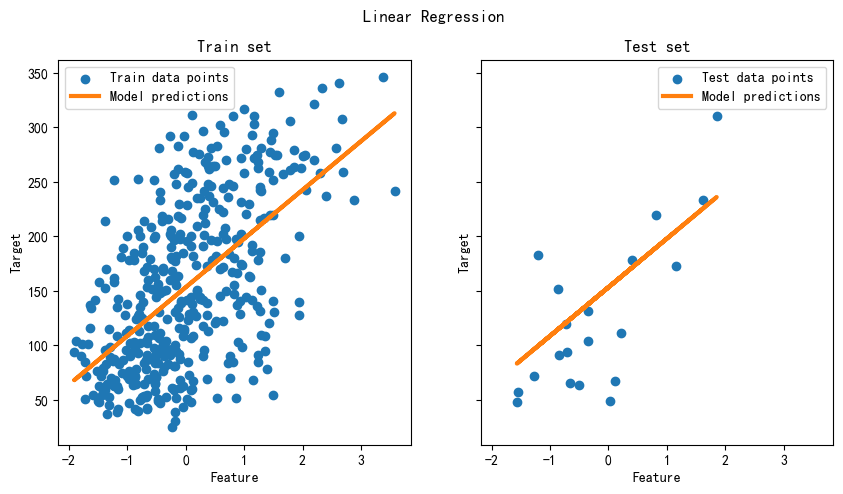

In [9]:
# 模块导入
from sklearn.datasets import load_diabetes #使用糖尿病数据集
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#1 数据加载
X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # 只保留一个特征
#2 数据划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)# shuffle=False表示不随机打乱数据集

# 3 特征工程
transfer= StandardScaler()
X_train=transfer.fit_transform(X_train)
X_test=transfer.transform(X_test)
#4 模型训练
regressor = LinearRegression()
#fit训练
regressor.fit(X_train,y_train)
print("模型中的系数为：\n",regressor.coef_)
print("模型中的偏置为：\n",regressor.intercept_)

#5 模型评估
y_pred = regressor.predict(X_test)
print("预测值为：\n",y_pred)
score=regressor.score(X_test,y_test)
print("准确率为：\n",score)
print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

#6 结果可视化
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()
ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()
fig.suptitle("Linear Regression")
plt.show()

## 2.逻辑回归-分类问题

### 2.1使用Sigmoid函数和梯度下降实现逻辑回归
步骤：
* 1.生成简单二分类数据
* 2.设置逻辑函数
* 3.初始化参数
* 4.梯度下降算法
* 5.模型预测与评估
* 6.结果可视化

训练准确率: 97.00%
学到的参数 (偏置, w1, w2): [-5.36683845  1.18466651  1.02360432]


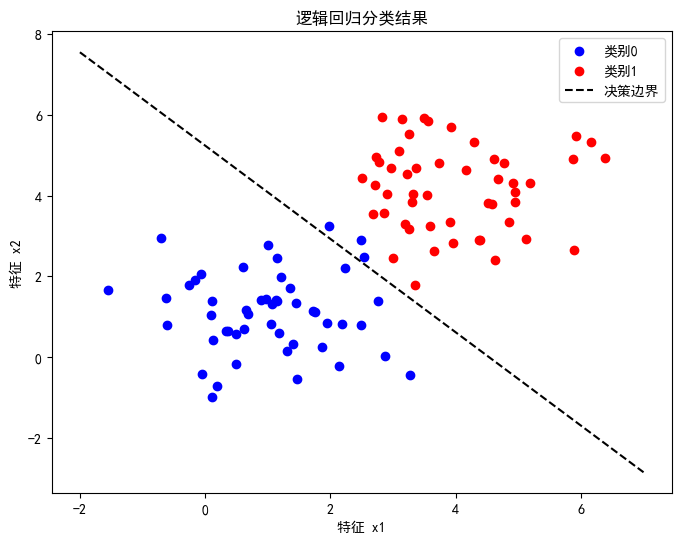

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1.生成简单二分类数据（两类各 50 个点）
np.random.seed(0)
m = 100
X0 = np.random.randn(50, 2) + [1, 1]
y0 = np.zeros(50)
X1 = np.random.randn(50, 2) + [4, 4]
y1 = np.ones(50)
X = np.vstack([X0, X1])
y = np.hstack([y0, y1])
X_b = np.c_[np.ones(m), X]     # 加一列 1 作为偏置项

# 2. 定义逻辑函数（sigmoid）
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
theta = np.random.randn(3)
lr = 0.1
epochs = 1000

# 4.梯度下降算法实现
losses = []
for epoch in range(epochs):
    # 前向传播：计算预测概率
    h = sigmoid(X_b @ theta)          # X_b @ theta 等价于 X_b.dot(theta)
    # 计算交叉熵损失（加微小项防止 log(0)）
    loss = -np.mean(y * np.log(h + 1e-15) + (1-y) * np.log(1-h + 1e-15))
    losses.append(loss)
    # 计算梯度： (1/m) * X_b^T (h - y)
    grad = (1/m) * X_b.T @ (h - y)
    # 更新参数
    theta -= lr * grad

# 5. 预测与评估
pred_prob = sigmoid(X_b @ theta)
pred_class = (pred_prob >= 0.5).astype(int)
acc = np.mean(pred_class == y)
print(f"训练准确率: {acc*100:.2f}%")
print("学到的参数 (偏置, w1, w2):", theta)

# 6.可视化（决策边界和散点）
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0,0], X[y==0,1], c='blue', label='类别0')
plt.scatter(X[y==1,0], X[y==1,1], c='red', label='类别1')
# 绘制决策边界
x1_vals = np.linspace(-2, 7, 100)
x2_vals = -(theta[0] + theta[1]*x1_vals) / theta[2]
plt.plot(x1_vals, x2_vals, 'k--', label='决策边界')
plt.xlabel('特征 x1')
plt.ylabel('特征 x2')
plt.legend()
plt.title('逻辑回归分类结果')
plt.show()

### 2.2使用scikit-learn实现逻辑回归
* 1.获取数据
* 2.基本数据处理
  * 2.1 缺失值处理
  * 2.2 确定特征值，目标值
  * 2.3 分割数据
* 3 特征工程
* 4.机器学习
* 5.模型评估

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score

# 1.获取数据
column_name = ['Sample code number', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',
                   'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
                   'Normal Nucleoli', 'Mitoses', 'Class']
data = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data",names=column_name)

# 2.基本数据处理

## 2.1 缺失值处理
data = data.replace(to_replace="?",value=np.nan)
data = data.dropna()
# 2.2 确定特征值和目标值
x= data.iloc[:,1:10]
y = data['Class']
# 2.3 分割数据
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=2,test_size=0.2)
# 3.特征工程(标准化)
transfer=StandardScaler()
x_train=transfer.fit_transform(x_train)
x_test=transfer.transform(x_test)

# 4.机器学习(逻辑回归)
estimator =LogisticRegression()
estimator.fit(x_train,y_train)

# 5.模型评估
# 5.1 预测值
y_pre =estimator.predict(x_test)
print("预测值是：\n",y_pre)

# 5.2 准确率值
score = estimator.score(x_test,y_test)
print("准确率是：\n",score)

# 5.3 精确率/召回率指标评价
ret=classification_report(y_test,y_pre)
print(ret)


预测值是：
 [4 4 2 4 2 2 2 2 2 4 2 2 4 2 2 2 4 4 2 2 2 2 4 4 4 2 2 4 2 4 4 4 4 2 4 2 4
 2 2 4 2 2 4 2 2 4 2 2 4 2 2 2 4 2 2 2 2 2 4 4 2 2 2 2 2 2 4 4 4 4 2 2 2 2
 2 2 2 2 4 4 4 4 4 2 4 4 4 2 4 2 2 4 4 4 2 4 2 4 2 2 4 2 2 2 2 4 4 2 2 2 2
 2 4 4 2 2 4 2 2 2 2 2 2 4 2 2 4 4 4 4 2 4 2 4 2 2 2]
准确率是：
 0.948905109489051
              precision    recall  f1-score   support

           2       0.96      0.95      0.96        83
           4       0.93      0.94      0.94        54

    accuracy                           0.95       137
   macro avg       0.95      0.95      0.95       137
weighted avg       0.95      0.95      0.95       137



## 3.决策树-回归与分类问题
决策树是一种非参数监督学习方法，用于分类和回归。

### 3.1决策树-回归问题
一维回归任务的决策树

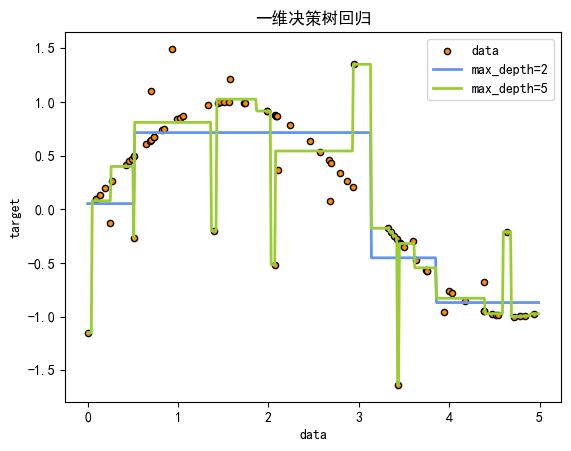

In [22]:
from sklearn.tree import DecisionTreeRegressor
# 1.创建随机一维数据集
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))
# 2.拟合回归模型
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)
# 3.预测
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)
# 4.绘制结果图
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("一维决策树回归")
plt.legend()
plt.show()

多输出目标的决策树回归<br/>
观察下图我们可以发现，如果树的最大深度max_depth设置得太高，决策树模型对训练数据学习得太细，它们会过度拟合。

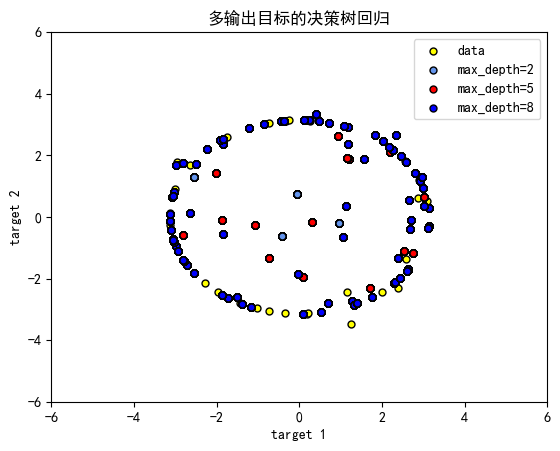

In [23]:
from sklearn.tree import DecisionTreeRegressor
# 1.创建数据集 
rng = np.random.RandomState(1)
X = np.sort(200 * rng.rand(100, 1) - 100, axis=0)
y = np.array([np.pi * np.sin(X).ravel(), np.pi * np.cos(X).ravel()]).T
y[::5, :] += 0.5 - rng.rand(20, 2)
# 2.拟合回归模型
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_3 = DecisionTreeRegressor(max_depth=8)
regr_1.fit(X, y)
regr_2.fit(X, y)
regr_3.fit(X, y)
# 3.预测
X_test = np.arange(-100.0, 100.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)
y_3 = regr_3.predict(X_test)
# 4.绘制结果图
plt.figure()
s = 25
plt.scatter(y[:, 0], y[:, 1], c="yellow", s=s, edgecolor="black", label="data")
plt.scatter(
    y_1[:, 0],
    y_1[:, 1],
    c="cornflowerblue",
    s=s,
    edgecolor="black",
    label="max_depth=2",
)
plt.scatter(y_2[:, 0], y_2[:, 1], c="red", s=s, edgecolor="black", label="max_depth=5")
plt.scatter(y_3[:, 0], y_3[:, 1], c="blue", s=s, edgecolor="black", label="max_depth=8")
plt.xlim([-6, 6])
plt.ylim([-6, 6])
plt.xlabel("target 1")
plt.ylabel("target 2")
plt.title("多输出目标的决策树回归")
plt.legend(loc="best")
plt.show()


### 3.2决策树-分类问题
使用鸢尾花数据集展示决策树的分类问题

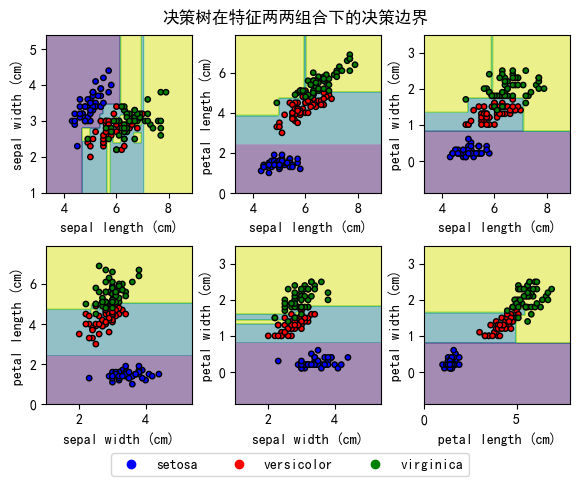

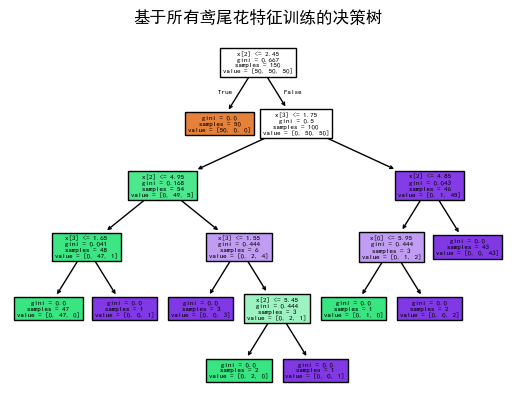

In [30]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.tree import plot_tree

# 1 数据准备
iris = load_iris()

# 2 遍历特征组合
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):

    X = iris.data[:, pair]
    y = iris.target

# 3 训练决策树
    clf = DecisionTreeClassifier().fit(X, y)

# 4 绘制决策边界
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict",
        ax=ax,
        xlabel=iris.feature_names[pair[0]],
        ylabel=iris.feature_names[pair[1]],
        alpha=0.5,
    )

# 5 绘制训练样本点
    scatter = disp.ax_.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
         cmap=ListedColormap(['blue', 'red', 'green']),
        edgecolor="black",
        s=15,
    )

plt.suptitle("决策树在特征两两组合下的决策边界")
plt.figlegend(
    scatter.legend_elements()[0],
    iris.target_names,
    loc="lower center",
    ncol=len(iris.target_names),
)
_ = plt.axis("tight")

# 6 决策树可视化
plt.figure()
clf = DecisionTreeClassifier().fit(iris.data, iris.target)
plot_tree(clf, filled=True)
plt.title("基于所有鸢尾花特征训练的决策树")
plt.show()

## 4.朴素贝叶斯-分类问题

### 4.1高斯朴素贝叶斯

朴素贝叶斯准确率: 89.00%


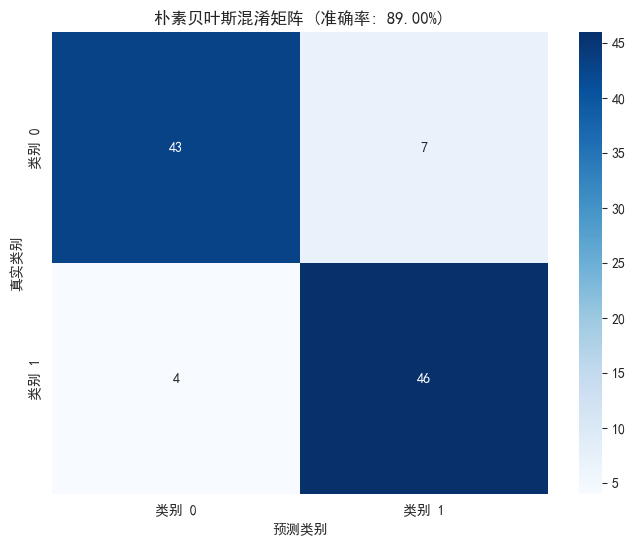

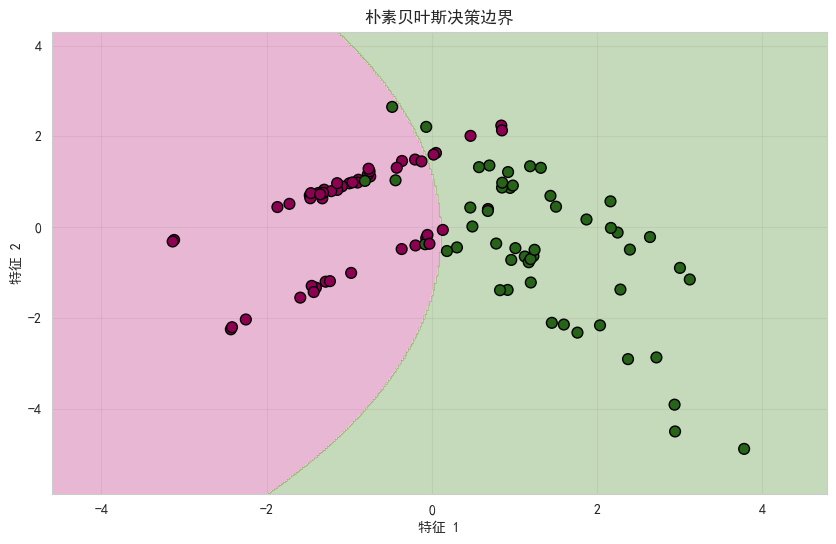

In [43]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
sns.set_style("whitegrid")

# 注意：解决中文显示问题 
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 数据准备（使用二分类数据）
X_clf, y_clf = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 2. 训练高斯朴素贝叶斯
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 3. 评估
y_pred = gnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"朴素贝叶斯准确率: {acc:.2%}")

# 4. 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['类别 0', '类别 1'],
            yticklabels=['类别 0', '类别 1'])
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title(f'朴素贝叶斯混淆矩阵 (准确率: {acc:.2%})')
plt.show()

# 5. 决策边界可视化
plt.figure(figsize=(10, 6))
x_min, x_max = X_clf[:, 0].min() - 1, X_clf[:, 0].max() + 1
y_min, y_max = X_clf[:, 1].min() - 1, X_clf[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.PiYG)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.PiYG, s=60)
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.title('朴素贝叶斯决策边界')
plt.grid(alpha=0.3)
plt.show()